# Ejemplo

Construir el polinomio de grado 1 para la funcion $f(x)=tan^{-1}x$,  entorno a $x_0=0$

El polinomio grado 1 es: $$P(x)=f(x_0)+f'(x_0)(x-x_0)$$

In [8]:
import numpy as np                 # Importa la librería NumPy para trabajar con funciones matemáticas como arctan

import matplotlib.pyplot as plt    # Importa matplotlib para graficar (aunque en este código no se usa)

import pandas as pd                # Importa pandas para crear y manejar tablas (DataFrame)

f = lambda x: np.arctan(x)         # Define la función original f(x) = arctan(x)

P = lambda x: x                    # Define el polinomio de Taylor de grado 1 en x0=0, que es P(x)=x

values = [1,3.5,5]                 # Lista de valores donde se evaluará la función, el polinomio y el error

def evaluacion(values, f, P):      # Define una función llamada evaluacion que recibe:
                                   # values -> lista de puntos a evaluar
                                   # f -> función original
                                   # P -> polinomio aproximante

    lista = []                     # Crea una lista vacía donde se guardarán los resultados

    for i in values:               # Recorre cada valor de la lista values

        lista.append([i,           # Guarda el valor de x
                      f(i),        # Calcula el valor real de la función f(x)
                      P(i),        # Calcula el valor aproximado con el polinomio P(x)
                      abs(f(i) - P(i))])  # Calcula el error absoluto |f(x) - P(x)|

    lista = pd.DataFrame(data=lista,   # Convierte la lista de resultados en una tabla tipo DataFrame
                         columns=['values_x',   # Columna del valor evaluado
                                  'f(x)',       # Columna del valor real de la función
                                  'P(x)',       # Columna del valor aproximado
                                  'Ea:|f(x)-P(x)|'])  # Columna del error absoluto

    return lista                  # Devuelve la tabla con todos los resultados

evaluacion(values, f, P)          # Llama la función evaluacion y muestra la tabla resultante

,values_x,f(x),P(x),Ea:|f(x)-P(x)|
0,1.0,0.785398,1.0,0.214602
1,3.5,1.292497,3.5,2.207503
2,5.0,1.373401,5.0,3.626599


Text(0, 0.5, 'Eje Y')

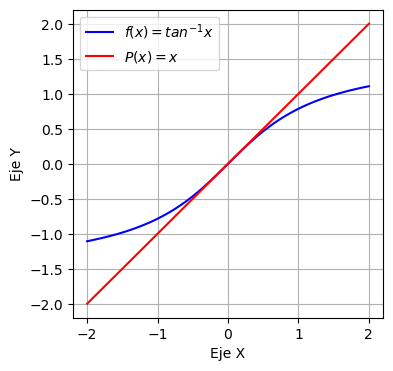

In [9]:
delta = 2   # Distancia hacia la izquierda y derecha desde el punto central
x0 = 0      # Punto central (porque es serie de Taylor en 0)
ux = np.linspace(x0 - delta, x0 + delta, 100) # Creamos 100 puntos entre -2 y 2
plt.figure(figsize=(4,4)) # Creamos la figura con tamaño 4x4
plt.plot(ux, f(ux), 'b', label='$f(x)=tan^{-1}x$') # Graficamos la función real en azul
plt.plot(ux, P(ux), 'r', label='$P(x)=x$') # Graficamos el polinomio aproximado en rojo
plt.legend() # Mostramos la leyenda
plt.grid() # Mostramos cuadrícula
plt.xlabel('Eje X') # Etiquetas de los ejes
plt.ylabel('Eje Y')

# Ejemplo:
Construir el polinomio de grado 5 para la función $f(x)=tan^{-1}x$, entorno a $x_0=0$

El polinomio de grado 5 es : $$P(x)=f(x_0)+f'(x_0)(x-x_0)+\frac{f''(x_0)}{2!}(x-x_0)^2+\frac{f'''(x_0)}{3!}(x-x_0)^3+\frac{f^{(4)}(x_0)}{4!}(x-x_0)^4+\frac{f^{(5)}(x_0)}{5!}(x-x_0)^5$$

In [11]:
import sympy as sp  # Importamos SymPy, que sirve para hacer matemáticas simbólicas
                    # (derivar, integrar, simplificar expresiones exactas).

x = sp.symbols('x') # Creamos la variable simbólica x.
                    # No es un número, es una letra matemática para trabajar algebraicamente.

F = sp.atan(x)      # Definimos la función simbólica F(x) = arctan(x).
                    # Aquí no se evalúa numéricamente, se guarda como expresión matemática.

# Calculamos la segunda derivada de F respecto a x
# El tercer argumento (2) significa que derivamos 2 veces
y_prime = sp.diff(F, x, 2)  
                    # sp.diff(F, x, 2) significa:
                    # Derivar F respecto a x, 2 veces.
                    # Es decir, estamos calculando F''(x).

df_eval = sp.lambdify(x, y_prime)  
                    # Convertimos la expresión simbólica F''(x)
                    # en una función numérica que Python pueda evaluar con números.
                    # Ahora df_eval funciona como una función normal.

print(df_eval(0))   # Evaluamos la segunda derivada en x = 0.
                    # Esto nos da el valor F''(0),
                    # que es necesario si estuviéramos construyendo
                    # el polinomio de Taylor de grado 2.

0.0


Evaluaciones:
\[
\begin{aligned}
f(0) &= 0\\
f'(0) &= 1\\
f''(0) &= 0\\
f^{(3)}(0) &= -2\\
f^{(4)}(0) &= 0\\
f^{(5)}(0) &= 24
\end{aligned}
\]


$$P(x)=(x-x_0)+\frac{-2}{3!}(x-x_0)^3+\frac{24}{5!}(x-x_0)^5$$

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import factorial
#import serie_taylor as st

f = lambda x: np.arctan(x)
P = lambda x: x - 2/factorial(3)*x**3 + 24/factorial(5)*x**5

values = [1, 3.5, 5]
print(evaluacion(values, f, P))

   values_x      f(x)        P(x)  Ea:|f(x)-P(x)|
0       1.0  0.785398    0.866667        0.081269
1       3.5  1.292497   94.252083       92.959587
2       5.0  1.373401  588.333333      586.959933


Text(0, 0.5, 'Eje Y')

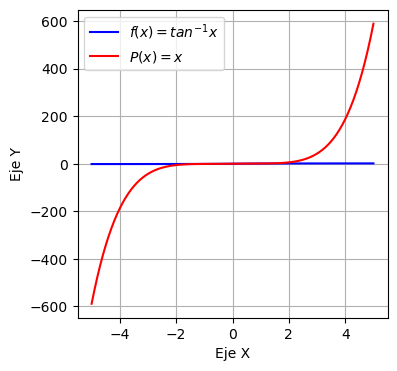

In [16]:
delta = 5   # Distancia hacia la izquierda y derecha desde el punto central
x0 = 0      # Punto central (porque es serie de Taylor en 0)
ux = np.linspace(x0 - delta, x0 + delta, 100) # Creamos 100 puntos entre -2 y 2
plt.figure(figsize=(4,4)) # Creamos la figura con tamaño 4x4
plt.plot(ux, f(ux), 'b', label='$f(x)=tan^{-1}x$') # Graficamos la función real en azul
plt.plot(ux, P(ux), 'r', label='$P(x)=x$') # Graficamos el polinomio aproximado en rojo
plt.legend() # Mostramos la leyenda
plt.grid() # Mostramos cuadrícula
plt.xlabel('Eje X') # Etiquetas de los ejes
plt.ylabel('Eje Y')
#plt.ylim(-20,20)

# Serie de Taylor

Sea una función $f(x)$ con derivadas de todos los órdenes en un punto $a$.

La **serie de Taylor** centrada en $a$ es:

$$
f(x)=\sum_{n=0}^{\infty}\frac{f^{(n)}(a)}{n!}(x-a)^n
$$

Equivalente a:

$$
f(x)=f(a)+f'(a)(x-a)+\frac{f''(a)}{2!}(x-a)^2+\frac{f^{(3)}(a)}{3!}(x-a)^3+\dots
$$


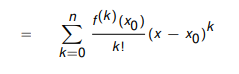

In [19]:
# Programación de la Serie de Taylor de orden n

import sympy as sp              # Librería para trabajar con matemáticas simbólicas
from math import factorial      # Función que calcula el factorial k! (necesario en la fórmula de Taylor)

x = sp.symbols('x')             # Definimos la variable simbólica x (variable algebraica, no numérica)

def Taylor_serie(f, x0, n):
    """
    Calcula el polinomio de Taylor de orden n
    de una función simbólica f centrado en x0.
    
    Parámetros:
    f  -> función simbólica (ej: sp.sin(x))
    x0 -> punto donde se centra la serie
    n  -> orden del polinomio
    
    Retorna:
    Polinomio de Taylor expandido
    """
    
    polinomio = 0               # Inicializamos el polinomio en 0 (aquí iremos acumulando los términos)

    for k in range(n + 1):      # Recorremos desde k = 0 hasta k = n
                                 # Cada k representa el orden de la derivada que estamos usando

        df = sp.diff(f, x, k)   # Calculamos la derivada k-ésima de la función f
                                 # Si k=0 → es la función original
                                 # Si k=1 → primera derivada
                                 # Si k=2 → segunda derivada, etc.

        df_eval = sp.lambdify(x, df)  
                                 # Convertimos la derivada simbólica en una función numérica
                                 # para poder evaluarla en un punto específico

        valor_derivada = df_eval(x0)  
                                 # Evaluamos la derivada k-ésima en el punto x0
                                 # Esto calcula f^(k)(x0)

        # Construimos el término general de Taylor:
        # (f^(k)(x0) / k!) * (x - x0)^k

        termino = (valor_derivada / factorial(k)) * (x - x0)**k  
                                 # Aplicamos directamente la fórmula matemática:
                                 #   f^(k)(x0)  → valor_derivada
                                 #   k!         → factorial(k)
                                 #   (x-x0)^k   → potencia correspondiente

        polinomio += termino    # Sumamos el término al polinomio acumulado

    return sp.expand(polinomio) # Expandimos el polinomio para simplificarlo y ordenarlo algebraicamente

In [22]:
F = sp.atan(x)        # Define la función simbólica F(x) = arctan(x)
                      # Aquí estamos usando SymPy, por eso es sp.atan y no np.arctan
                      # F queda como una expresión matemática simbólica

Taylor_serie(F, 0, 5) # Llama la función Taylor_serie que programaste antes
                      # Parámetros:
                      # F  → función a aproximar (arctan(x))
                      # 0  → punto donde se centra la serie (x0 = 0)
                      # 5  → orden del polinomio (grado 5)
                      #
                      # Esto calcula:
                      # P_5(x) = Σ ( f^(k)(0) / k! ) (x - 0)^k
                      # desde k = 0 hasta k = 5

0.2*x**5 - 0.333333333333333*x**3 + 1.0*x